In [17]:
import pandas as pd
import numpy as np

np.random.seed(23)

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0], [0,1,0], [0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample, columns=['feature1', 'feature2', 'feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0], [0,1,0], [0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample, columns=['feature1', 'feature2', 'feature3'])
df1['target'] = 0

df = pd.concat([df, df1], ignore_index=True)
df = df.sample(40)

In [18]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


In [19]:

import plotly.express as px
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
              color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()

In [20]:
# Step-1 Apply standard scaling(mean centering)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [21]:
# Step 2 - Find Covariance Matrix
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [22]:
# Step 3 - Finding EV and EVs
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [23]:
eigen_values

array([1.3536065 +0.j, 0.94557084+0.j, 0.77774573+0.j])

In [24]:
eigen_vectors 

array([[-0.53875915+0.j, -0.69363291+0.j,  0.47813384+0.j],
       [-0.65608325+0.j, -0.01057596+0.j, -0.75461442+0.j],
       [-0.52848211+0.j,  0.72025103+0.j,  0.44938304+0.j]])

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


C:\Users\praja\AppData\Roaming\Python\Python314\site-packages\matplotlib\transforms.py:1913: ComplexWarning: Casting complex values to real discards the imaginary part
  return affine_transform(values, mtx)


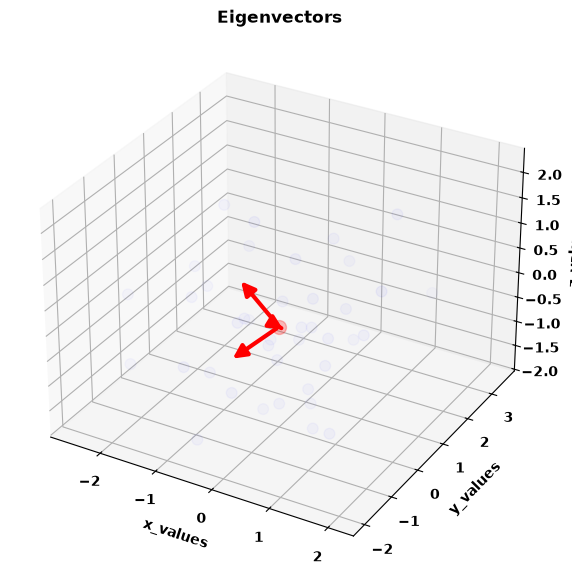

In [25]:
%pylab inline

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch
import numpy as np


class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        self._verts3d = xs, ys, zs
        
        # Required for newer Matplotlib versions
        super().__init__(
            (0, 0),
            (0, 0),
            *args,
            **kwargs
        )

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        
        xs, ys, zs = proj3d.proj_transform(
            xs3d,
            ys3d,
            zs3d,
            self.axes.M
        )
        
        self.set_positions(
            (xs[0], ys[0]),
            (xs[1], ys[1])
        )
        
        super().draw(renderer)

    # Required for Matplotlib >= 3.8
    def do_3d_projection(self):
        xs3d, ys3d, zs3d = self._verts3d
        
        xs, ys, zs = proj3d.proj_transform(
            xs3d,
            ys3d,
            zs3d,
            self.axes.M
        )
        
        self.set_positions(
            (xs[0], ys[0]),
            (xs[1], ys[1])
        )
        
        return np.min(zs)


fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot data points
ax.scatter(
    df['feature1'],
    df['feature2'],
    df['feature3'],
    s=60,
    color='blue',
    alpha=0.2
)

# Plot mean point
mean_point = [
    df['feature1'].mean(),
    df['feature2'].mean(),
    df['feature3'].mean()
]

ax.scatter(
    mean_point[0],
    mean_point[1],
    mean_point[2],
    s=100,
    color='red',
    alpha=0.5
)

# Plot eigenvectors
for v in eigen_vectors.T:
    a = Arrow3D(
        [mean_point[0], mean_point[0] + v[0]],
        [mean_point[1], mean_point[1] + v[1]],
        [mean_point[2], mean_point[2] + v[2]],
        mutation_scale=20,
        lw=3,
        arrowstyle="-|>",
        color="red"
    )
    ax.add_artist(a)


ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')

plt.title('Eigenvectors')

plt.show()

In [26]:
pc = eigen_vectors[0:2]
pc

array([[-0.53875915+0.j, -0.69363291+0.j,  0.47813384+0.j],
       [-0.65608325+0.j, -0.01057596+0.j, -0.75461442+0.j]])

In [27]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,0.599433+0.000000j,1.795862+0.000000j,1
1,1.056919+0.000000j,-0.212737+0.000000j,0
2,-0.271876+0.000000j,0.498222+0.000000j,1
3,-0.621586+0.000000j,0.023110+0.000000j,1
4,1.567286+0.000000j,1.730967+0.000000j,1


In [28]:
print(new_df['PC1'].head())
print(type(new_df['PC1'].iloc[0]))

print(new_df['PC2'].head())
print(type(new_df['PC2'].iloc[0]))

0    0.599433+0.000000j
1    1.056919+0.000000j
2   -0.271876+0.000000j
3   -0.621586+0.000000j
4    1.567286+0.000000j
Name: PC1, dtype: complex128
<class 'numpy.complex128'>
0    1.795862+0.000000j
1   -0.212737+0.000000j
2    0.498222+0.000000j
3    0.023110+0.000000j
4    1.730967+0.000000j
Name: PC2, dtype: complex128
<class 'numpy.complex128'>


In [29]:
new_df['PC1'] = np.real(new_df['PC1'])
new_df['PC2'] = np.real(new_df['PC2'])

new_df['target'] = new_df['target'].astype(str)

In [30]:
fig = px.scatter(
    new_df,
    x='PC1',
    y='PC2',
    color='target',
    color_discrete_sequence=px.colors.qualitative.G10
)

fig.update_traces(
    marker=dict(
        size=12,
        line=dict(width=2, color='DarkSlateGrey')
    )
)

fig.show()